<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# TS5: Estimación espectral: Ancho de banda de señales reales
#### Sofía Makkos

#### Introducción

En el presente trabajo, se analizarán señales desconocidas hasta ahora para nosotros, tales como las de estudios médicos, Electrocardiograma y Pletismografía, y audios en formato .wav, la tonada de La Cucaracha, una prueba de sonido y un silbido. Además, se diferenciará entre aquellas señales con y sin ruido, es decir, que hayan atravesado un proceso de filtrado previamente.

Para conseguir una estimación sobre los PSD de cada caso, se utilizará el método de Welch, siempre utilizando *K*=33;35;37, con un solapamiento *D* del 50%, un *L* dependiente de la cantidad de muestras *N* y una ventana Hann *w(n)* (arbitraria). Con los parámetros mencionados, entonces, se pueden completar las siguientes fórmulas:
\begin{equation}
\widehat{P}_W(e^{jw})=\frac{1}{KLU}\sum_{i=0}^{K-1}|\sum_{n=0}^{L-1}w(n)x(n+iD)e^{-jnw}|^2
\end{equation}
\begin{equation}
U=\frac{1}{L}\sum_{n=0}^{L-1}|w(n)|^2
\end{equation}

Con esta última fórmula, calculamos la energía de la ventana aplicada, para luego normalizar el periodograma con respecto a esta *U*.
Mediante el código, emplearemos una función *scipy.signal.welch*, que nos devolverá los valores de amplitud de PSD y sus respectivas frecuencias.

Luego, se buscará los anchos de banda de cada señal con ciertos criterios de límites superior e inferior, observando dónde se concentra la gran parte de la potencia en cada PSD.

#### Desarrollo

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy import signal as sig
import pandas as pd

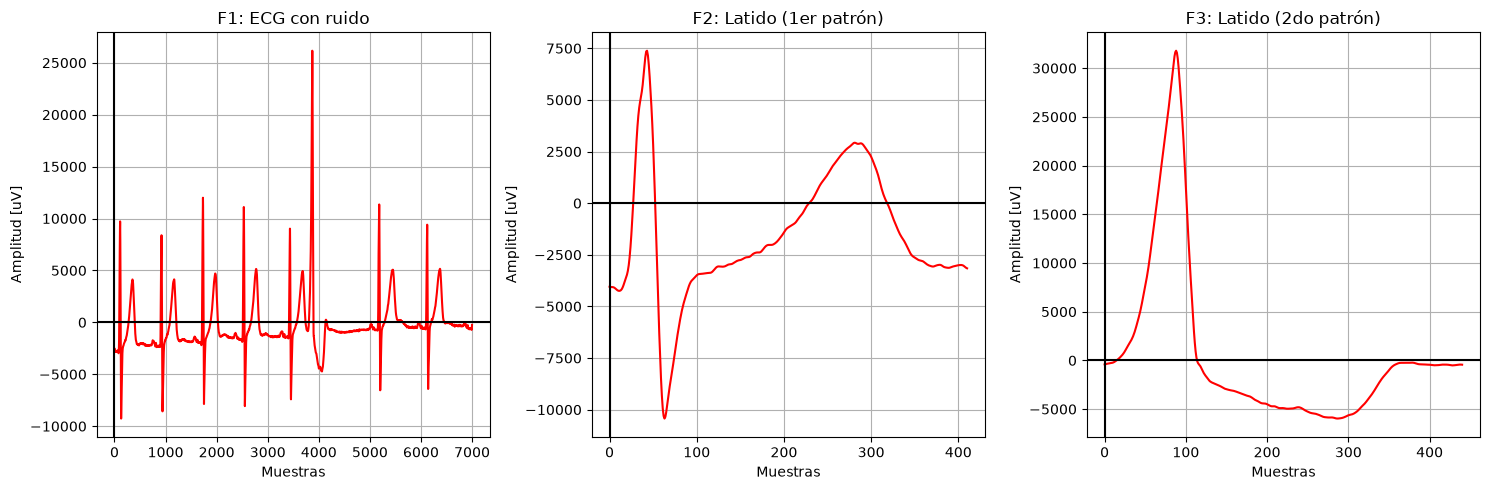

In [2]:
#%% ECG con ruido

fs_ECG = 1000

# para listar las variables que hay en el archivo
sio.whosmat('ECG_TP4.mat')
mat_struct = sio.loadmat('./ECG_TP4.mat')

ecg_one_lead_ruido = mat_struct['ecg_lead']
N = len(ecg_one_lead_ruido)

hb_1 = mat_struct['heartbeat_pattern1']
hb_2 = mat_struct['heartbeat_pattern2']

plt.figure(1, figsize=(15,5))
plt.subplot(1,3,1)
plt.plot(ecg_one_lead_ruido[5000:12000], color="red")
plt.title("F1: ECG con ruido")
plt.axhline(0,color="black")
plt.axvline(0,color="black")
plt.grid()
plt.xlabel("Muestras")
plt.ylabel("Amplitud [uV]")
plt.tight_layout() 

plt.subplot(1,3,2)
plt.plot(hb_1, color="red")
plt.title("F2: Latido (1er patrón)")
plt.axhline(0,color="black")
plt.axvline(0,color="black")
plt.grid()
plt.xlabel("Muestras")
plt.ylabel("Amplitud [uV]")
plt.tight_layout() 

plt.subplot(1,3,3)
plt.plot(hb_2, color="red")
plt.title("F3: Latido (2do patrón)")
plt.axhline(0,color="black")
plt.axvline(0,color="black")
plt.grid()
plt.xlabel("Muestras")
plt.ylabel("Amplitud [uV]")
plt.tight_layout() 

Mediante la lectura del archivo ECG_TP4.mat, se graficaron las mediciones del electrocardiograma en virtud de las muestras tomadas. La *Figura 1* aparenta tener cierto desplazamiento con respecto al eje de abscisas, que a continuación se verá corregido al observar el ECG sin ruido. Por otro lado, las otras dos figuras representan dos latidos específicos elegidos entre los varios existentes.

<img src="./electrocardiograma.jpg" align="center" width="500" /> 

Con esta imagen, podemos reconocer las secciones de cada latido. Por ejemplo, la *Figura 2* representa el Intervalo QT, mientras que la *Figura 3* podría indicar que se trate de un recorte de esta última porción, siendo que toma las muestras entre el punto Q hasta el final del segmento ST. Esta apreciación no es un exacta, ya que el pico S no se observa como tal.

Por otro lado, los picos R en las tres figuras varían considerablemente. Esto podría deberse a las actividades realizadas durante el estudio médico, siendo este una prueba de esfuerzo.

Text(0, 0.5, 'Amplitud [uV]')

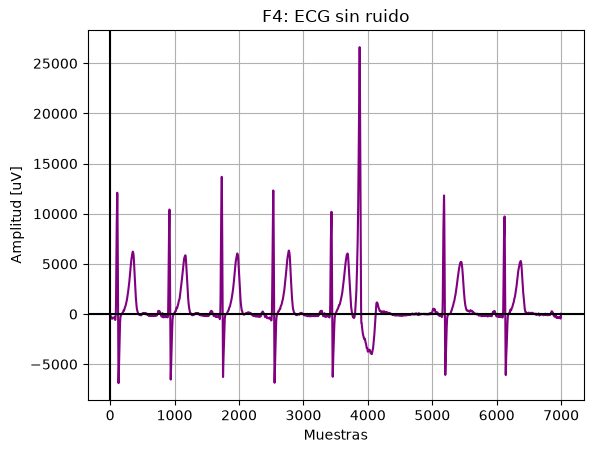

In [3]:
#%% ECG sin ruido

ecg_one_lead = np.load('ecg_sin_ruido.npy')

plt.figure(4)
plt.plot(ecg_one_lead[5000:12000], color="purple")
plt.axhline(0,color="black")
plt.axvline(0,color="black")
plt.grid()
plt.title("F4: ECG sin ruido")
plt.xlabel("Muestras")
plt.ylabel("Amplitud [uV]")

A disposición de un segundo archivo del ECG sin ruido, se graficó este, demostrando así la alineación con el eje x, para así tener una mejor apreciación de los resultados. Los picos R y S siguen siendo los mismos que antes, aunque corridos en amplitud. A la vez, se puede observar todavía cómo, aproximadamente en las 4000 muestras, aquella depresión S mantuvo ese formato peculiar, distintivo con respecto a los demás.

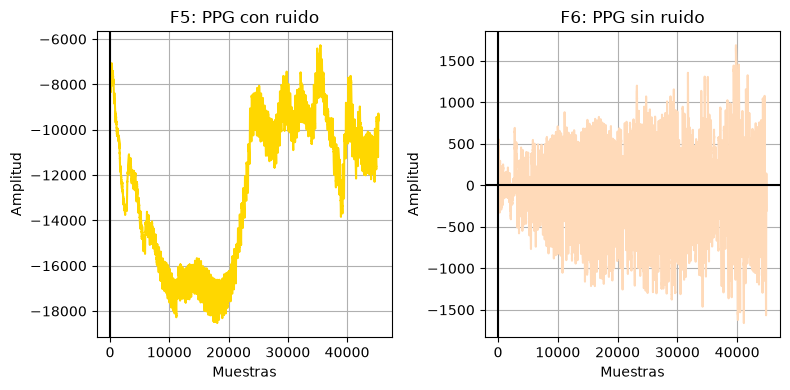

In [4]:
fs_ppg = 400

ppg_ruido = np.genfromtxt('PPG.csv', delimiter=',', skip_header=1)
plt.figure(5, figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(ppg_ruido, color="gold")
plt.title("F5: PPG con ruido")
plt.axvline(0,color="black")
plt.grid()
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.tight_layout() 

#%% Pletismografía sin ruido

ppg = np.load('ppg_sin_ruido.npy')
plt.subplot(1,2,2)
plt.plot(ppg, color="peachpuff")
plt.title("F6: PPG sin ruido")
plt.axhline(0,color="black")
plt.axvline(0,color="black")
plt.grid()
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.tight_layout() 

En estas nuevas gráficas, vemos ahora una gran diferenciación entre la señal previo y posterior al filtro para atenuar el ruido. Mientras que en la primera figura las amplitudes toman únicamente valores negativos, la segunda evidencia cierta media nula, tanto con valores positivos como negativos, aumentando estos progresivamente y reflejados.

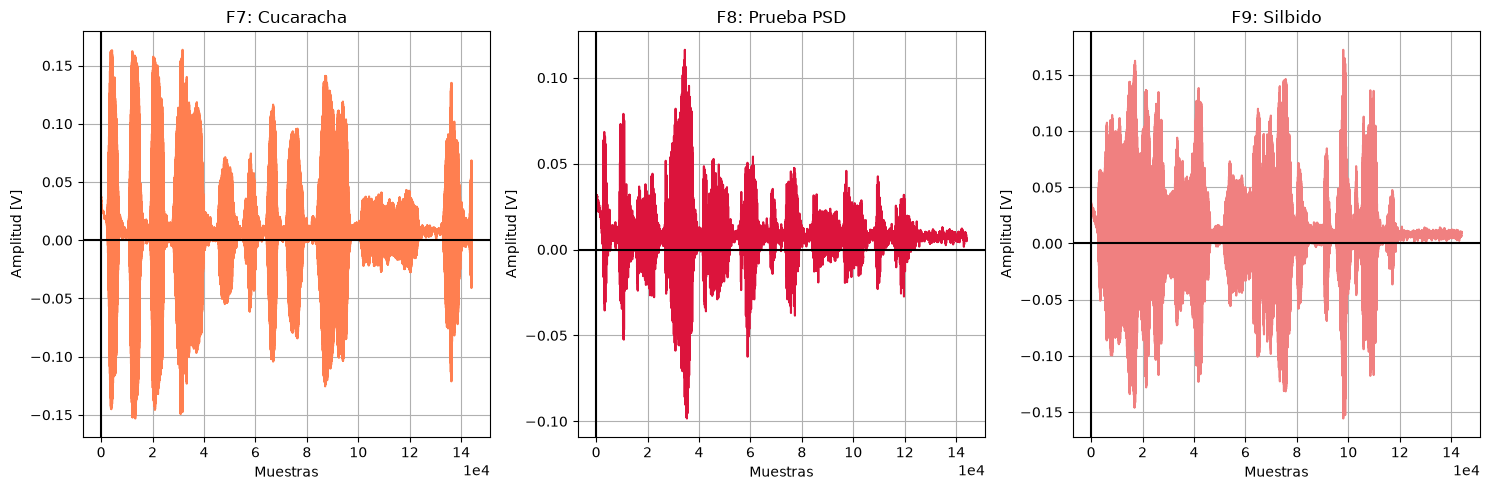

In [5]:
#%% Lectura de audios
fs_audio1, cucaracha = sio.wavfile.read('la cucaracha.wav')
fs_audio2, prueba = sio.wavfile.read('prueba psd.wav')
fs_audio3, silbido = sio.wavfile.read('silbido.wav')

plt.figure(6, figsize=(15,5))
plt.subplot(1,3,1)
plt.plot(cucaracha, color="coral")
plt.title("F7: Cucaracha")
plt.axhline(0,color="black")
plt.axvline(0,color="black")
plt.grid()
plt.ticklabel_format(axis='x', style='sci', scilimits=(4, 4))
plt.xlabel("Muestras")
plt.ylabel("Amplitud [V]")
plt.tight_layout() 

plt.subplot(1,3,2)
plt.plot(prueba, color="crimson")
plt.title("F8: Prueba PSD")
plt.axhline(0,color="black")
plt.axvline(0,color="black")
plt.grid()
plt.ticklabel_format(axis='x', style='sci', scilimits=(4, 4))
plt.xlabel("Muestras")
plt.ylabel("Amplitud [V]")
plt.tight_layout() 

plt.subplot(1,3,3)
plt.plot(silbido, "lightcoral")
plt.title("F9: Silbido")
plt.axhline(0,color="black")
plt.axvline(0,color="black")
plt.grid()
plt.ticklabel_format(axis='x', style='sci', scilimits=(4, 4))
plt.xlabel("Muestras")
plt.ylabel("Amplitud [V]")
plt.tight_layout() 

Finalmente, tenemos las representaciones gráficas de los sonidos. Las amplitudes en este caso, varían según la intensidad del ruido grabado, siendo que en silencios la amplitud se acerca al eje de abscisas, y con mucho sonido que generan picos más pronunciados. Es interesante cómo las tres señales evidencian aproximadamente el mismo rango de amplitudes, siendo que se grabaron con el mismo dispositivo. Además, la *Figura 7* al igual que la *Figura 9* son silbidos, mientras que la *Figura 8* se trata de una prueba de voz, por lo que la sutil diferencia se nota en los máximos.

Por otro lado, es fácil reconocer que las tres señales se encuentran desfasadas con respecto a al eje x, probablemente debido a la aparición de cierto "ruido" o al método imperfecto de la grabación de los audios.

#### Método de Welch

In [6]:
def welch_señal(señal, minimo, maximo, fs, fig, nombre,e):
    N=len(señal)
    L= np.array([N//33, N//35, N//37])
    K=N/L
    arrwelch_señal=[]
    for l in L:
        welch_señal = sig.welch(señal,fs,'hann',l,l/2,N)   
        arrwelch_señal.append(welch_señal)

    plt.figure(fig, figsize=(8, 4))
    plt.subplot(1,2,1)
    for i in range(len(arrwelch_señal)):
        plt.plot(arrwelch_señal[i][0],arrwelch_señal[i][1],label=f'K = {K[i]:.0f}')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Densidad espectral de potencia')
    plt.title(f"F{fig}: {nombre}")
    plt.legend()
    plt.grid()
    plt.ticklabel_format(axis='y', style='sci', scilimits=(e, e))
    plt.tight_layout() 
    
    plt.subplot(1,2,2)
    for i in range(len(arrwelch_señal)):
        plt.plot(arrwelch_señal[i][0][minimo:maximo],arrwelch_señal[i][1][minimo:maximo],label=f'K = {K[i]:.0f}')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Densidad espectral de potencia')
    plt.title(f"F{fig+1}: {nombre}")
    plt.legend()
    plt.grid()
    plt.ticklabel_format(axis='y', style='sci', scilimits=(e, e))
    plt.tight_layout() 
    return arrwelch_señal, K

De manera de simplificación, definí una función genérica para cada señal, de manera que no se observen repetidas líneas de código. Los parámetros representan lo siguiente:
- *señal*: Señal a la que se le aplicará el método de Welch. A partir de esta también se determinará el N (muestras).
- *minimo* y *maximo*: límites para generar un acercamiento en el gráfico y observar las diferencias entre los *K*.
- *fs*: frecuencia de sampleo para cada señal (ECG y PPG indicados previamente, frecuencias de los sonidos elegidos arbitrariamente).
- *fig*: número de figura, para evitar solapamiento.
- *nombre*: título de cada gráfico.
- *e*: a qué exponente estarán presentadas las amplitudes en los gráficos.

La función *welch* requiere la señal, la frecuencia de sampleo, la ventana a aplicar, la longitud de las muestras, su solapamiento y la cantidad de muestras.

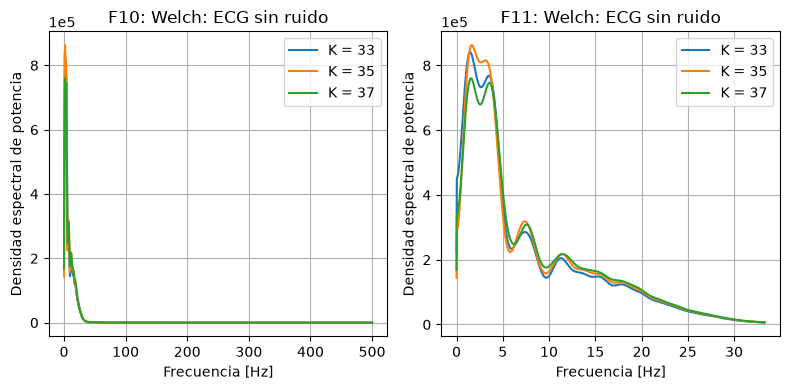

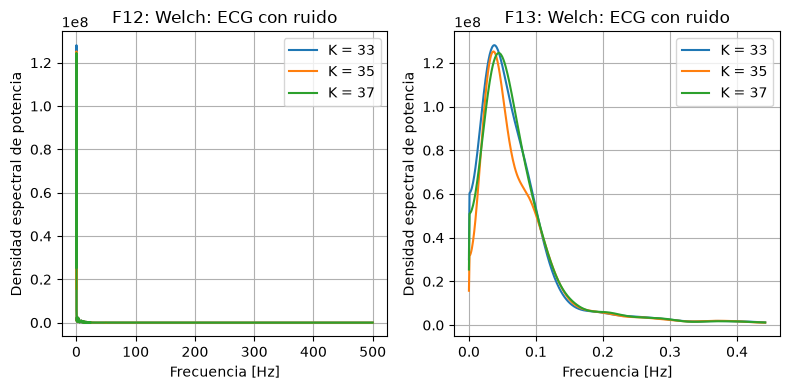

In [7]:
welch_ECG, K=welch_señal(ecg_one_lead, 0, 1000, 1000, 10, "Welch: ECG sin ruido", 5) 
ecg_one_lead_ruido = ecg_one_lead_ruido.flatten()
welch_ECG_ruido, K=welch_señal(ecg_one_lead_ruido, 0, 500, 1000, 12, "Welch: ECG con ruido", 8)

Mediante la ampliación de las figuras, tenemos una mejor percepción de la distinción entre los *K*. Una peculiaridad en el ECG sin ruido, es la generación de ciertas perturbaciones a pesar de ser una señal "limpia". Esto podría deberse a la cantidad de muestras *N* o por la especificidad posterior al filtrado, con respecto al electrocardiograma con ruido.

Las dos señales cuentan con *N* distinto:

In [8]:
print(f"N ECG con ruido: {len(ecg_one_lead_ruido)}, N ECG sin ruido: {len(ecg_one_lead)}")

N ECG con ruido: 1129116, N ECG sin ruido: 30000


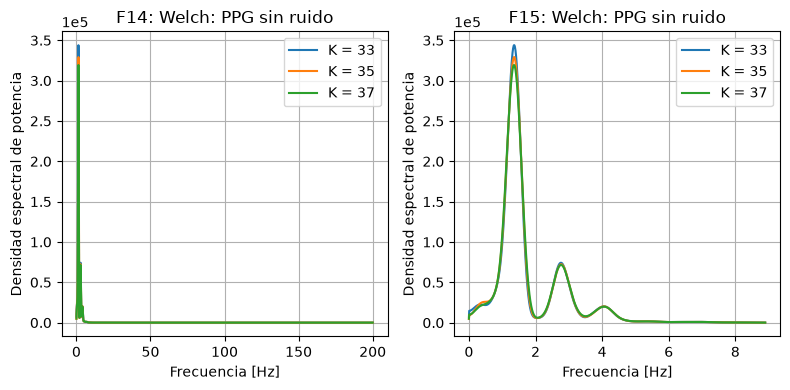

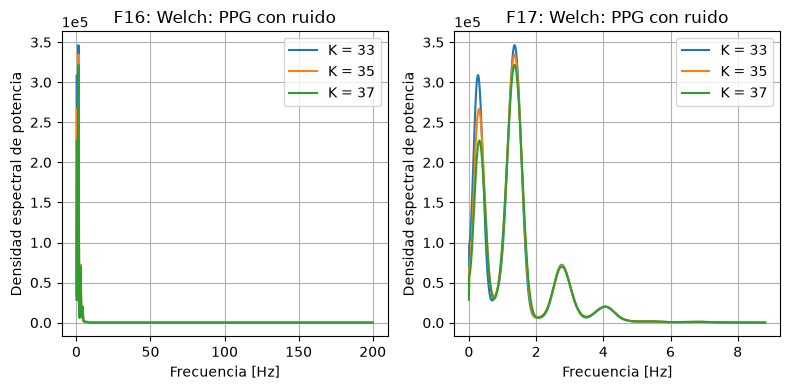

In [9]:
welch_ppg, K=welch_señal(ppg, 0, 1000, 400, 14, "Welch: PPG sin ruido", 5)
welch_ppg_ruido, K=welch_señal(ppg_ruido, 0, 1000, 400, 16, "Welch: PPG con ruido",5)

En esta situación, la gran diferencia entre la Pletismografía con y sin ruido, es el pico cercano al cero. Luego del filtrado, este salto de amplitud se debió haber visto como ajeno a los resultados comunes del PPG, por lo que se quitó para la disposición final. Fuera de ello, las señales presentan los mismos picos y cumbres, y además casi la misma cantidad de muestras N:

In [10]:
print(f"N PPG con ruido: {len(ppg_ruido)}, N PPG sin ruido: {len(ppg)}")

N PPG con ruido: 45319, N PPG sin ruido: 44919


Además, mientras menor es el *K*, mayor es la amplitud del PSD, factor que no se observó en los periodogramas de los ECG.

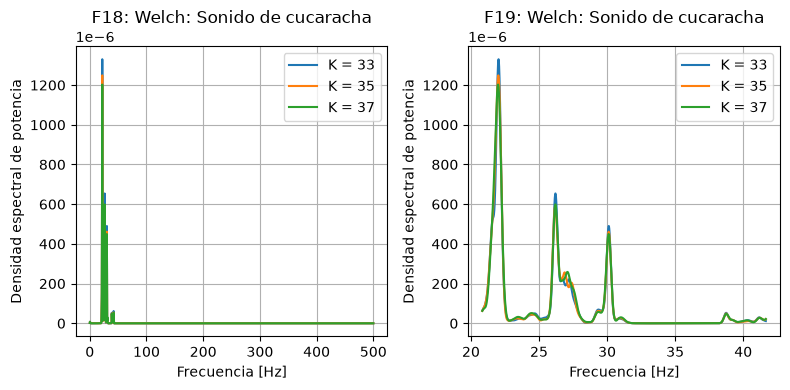

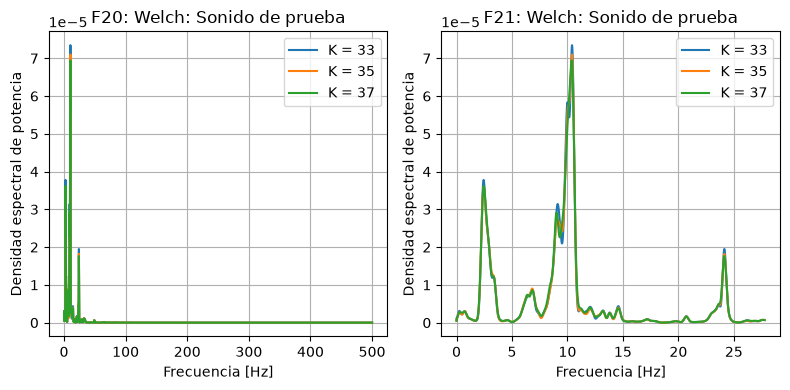

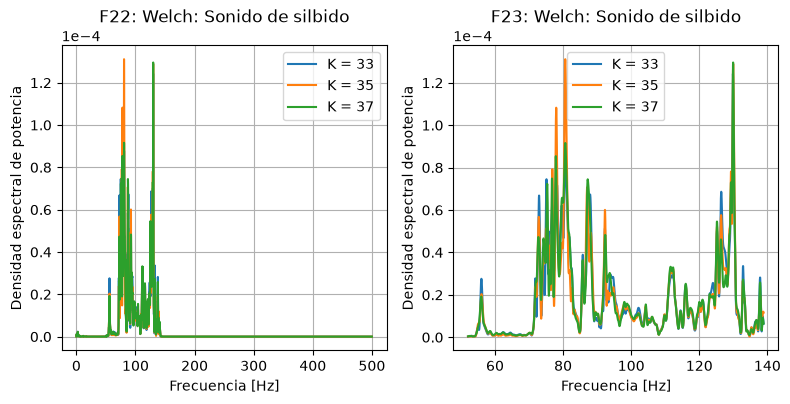

In [11]:
welch_cucaracha, K=welch_señal(cucaracha, 3000, 6000, 1000, 18, "Welch: Sonido de cucaracha",-6)
welch_prueba, K=welch_señal(prueba, 0, 4000, 1000, 20, "Welch: Sonido de prueba",-5)
welch_silbido, K=welch_señal(silbido, 7500, 20000, 1000, 22, "Welch: Sonido de silbido", -4)

En cuanto a los sonidos analizados, se puede apreciar cómo la autocorrelación juega un papel importante en los periodogramas. Como la canción de La Cucaracha presenta un ritmo y melodía propios, se ve una progresión decayente en los picos de manera parcialmente simétrica. Es lógico considerar que la señal presenta mayor autocorrelación que los otros dos sonidos, siendo estos aleatorios.

Además, para los dos primeros espectros, la variación del *K* no pareció generar grandes cambios, mientras que para la *Figura 22*, más específicamente en la *Figura 23*, los picos se ven modificados considerablemente. 

#### Anchos de banda

In [12]:
def ancho_banda(welch, K):
    suma=0
    sum_prim=0
    sum_ult=0
    for i in range(len(welch)):
        freq = welch[i][0]
        psd = welch[i][1]
        resol = freq[1] - freq[0]
        potencia = np.cumsum(psd) * resol
        prim_indice = np.searchsorted(potencia,0.005 * potencia[-1])
        ult_indice = np.searchsorted(potencia, 0.995 * potencia[-1])
        prim_freq = freq[prim_indice]
        ult_freq = freq[ult_indice]
        bw = ult_freq - prim_freq
        sum_prim+=prim_freq
        sum_ult+=ult_freq
        suma+=bw
    prom=suma/len(welch)
    prom_prim=sum_prim/3
    prom_ult=sum_ult/3
    return prom_prim, prom_ult, prom

Nuevamente, defino una función genérica para el cálculo del ancho de banda. Por decisión propia, se realizará un promedio por cada ancho de banda y sus extremos con respecto a cada *K*. A manera de estimar, se consideró que el ancho de banda se encuentre entre el 0,5 y 99,5% de la potencia total de cada señal, para así descartar rangos innecesarios. Se tomó la frecuencia de cada límite, y luego se realizó la diferencia entre ellos, para así conseguir el ancho de banda estimado.

In [13]:
prim_ECG, ult_ECG, bw_ECG=ancho_banda(welch_ECG, K)
prim_ECG_ruido, ult_ECG_ruido, bw_ECG_ruido=ancho_banda(welch_ECG_ruido, K)
prim_ppg, ult_ppg, bw_ppg=ancho_banda(welch_ppg, K)
prim_ppg_ruido, ult_ppg_ruido, bw_ppg_ruido=ancho_banda(welch_ppg_ruido, K)
prim_cucaracha, ult_cucaracha, bw_cucaracha=ancho_banda(welch_cucaracha, K)
prim_prueba, ult_prueba, bw_prueba=ancho_banda(welch_prueba, K)
prim_silbido, ult_silbido, bw_silbido=ancho_banda(welch_silbido, K)

In [14]:
df = pd.DataFrame({"Señal": ["Electrocardiograma con ruido", "Electrocardiograma sin ruido", "Pletismografía con ruido","Pletismografía sin ruido", "La Cucaracha", "Prueba de sonido", "Silbido"], "Límite inferior": [prim_ECG_ruido.round(3), prim_ECG.round(3), prim_ppg_ruido.round(3), prim_ppg.round(3), prim_cucaracha.round(3), prim_prueba.round(3), prim_silbido.round(3)], "Límite superior": [ult_ECG_ruido.round(3), ult_ECG.round(3), ult_ppg_ruido.round(3), ult_ppg.round(3), ult_cucaracha.round(3), ult_prueba.round(3), ult_silbido.round(3)], "Ancho de banda": [bw_ECG_ruido.round(3), bw_ECG.round(3), bw_ppg_ruido.round(3), bw_ppg.round(3), bw_cucaracha.round(3), bw_prueba.round(3), bw_silbido.round(3)]})
df

,Señal,Límite inferior,Límite superior,Ancho de banda
0,Electrocardiograma con ruido,0.002,31.069,31.066
1,Electrocardiograma sin ruido,0.089,35.933,35.844
2,Pletismografía con ruido,0.024,6.290,6.267
3,Pletismografía sin ruido,0.113,6.780,6.667
4,La Cucaracha,20.528,42.123,21.595
5,Prueba de sonido,0.377,79.271,78.894
6,Silbido,54.789,140.141,85.352


En la tabla se inlcuyó tanto el Ancho de banda de cada uno, como sus extremos, de manera que se considere también la separación de ciertos Bw del eje y. 
- Los electrocardiogramas con y sin ruido cuentan con anchos de banda similares, probablemente modificados debido a expansión de la potencia a lo largo de las frecuencias luego del filtrado aplicado.
- Las pletismografías disponen de límites inferior y superior distintos, sin embargo, el ancho de banda acaba siendo el mismo. Por lo tanto, podemos considerar que, luego de atenuar el ruido, el ancho de banda se vio desplazado hacia mayores frecuencias.
- Los sonidos experimentados tienen Bws variados, claramente debido a que no tienen relación alguna entre ellos. Sin embargo, es interesante destacar cómo las dos grabaciones realizadas a partir de silbidos cuentan con un límite inferior distinto de los demás, siendo que sonidos tan intensos y agudos llevan al ancho de banda a frecuencias más altas.

#### Conclusiones

En la experimentación de los nuevos tipos de señales presentados, analizamos sus naturalezas comparando los resultados con casos conocidos, como el caso del electrocardiograma. Para este, se estudió la presencia de intervalos y picos relevantes. En cuanto a la Pletismografía, se desconoce el origen de los resultados, ya que no se especifica el tipo de estudio realizado (PPG pulmonar o vascular) ni las unidades. Con respecto a los estudios con y sin ruido, se observó principalmente una alineación con el eje de abscisas en ambos casos. En particular con el PPG, la representación de su PSD demostró cambios importantes con y sin ruido, teniendo este último un pico significativo menos. 

Sobre las grabaciones de sonido, se vieron formatos similares en cuanto a los gráficos de cada señal, aunque diferencias en las densidades espectrales de potencia y sus anchos de banda. La autocorrelación de estos audios influyó directamente en la aplicación de Welch. 